# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [14]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [15]:
# TODO: Load your dataset(s) here.
# Update the path below to your actual data file.

# https://www.kaggle.com/datasets/himadri07/malicious-urls-dataset-15k-rows

DATA_PATH = '../data/Malicious_URL_v3.csv'

df = pd.read_csv(DATA_PATH)
df.head()

,Unnamed: 0,url,type
0,0,br-icloud.com.br,phishing
1,1,mp3raid.com/music/krizz_kaliko.html,benign
2,2,bopsecrets.org/rexroth/cr/1.htm,benign
3,3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [16]:
# Verify the data loaded correctly by displaying shape and a sample
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.sample(5)

Dataset shape: 49750 rows x 3 columns


,Unnamed: 0,url,type
46485,46485,http://www.fonatsch.at/index.php/kontakt/ihre-...,defacement
37415,37415,airforcetimes.com/news/2009/09/airforce_octobe...,benign
405,405,answers.com/topic/the-northern-pikes,benign
31219,31219,amazon.com/Saint-George-Dragon-Margaret-Hodges...,benign
33737,33737,http://www.slab.ro/index.php?option=com_conten...,defacement


In [17]:
data_source_report = {
    "source": "Kaggle",
    "acquisition_method": "CSV download",
    "date_acquired": "2026-03-31",
    "issues_encountered": [
        "None encountered during acquisition."
    ]
}
print(data_source_report)

{'source': 'Kaggle', 'acquisition_method': 'CSV download', 'date_acquired': '2026-03-31', 'issues_encountered': ['None encountered during acquisition.']}


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [18]:
# TODO: Describe the structure and schema of your data.
# Inspect data types, non-null counts, and memory usage.

# df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49750 entries, 0 to 49749
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  49750 non-null  int64
 1   url         49750 non-null  str  
 2   type        49750 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.1 MB


In [19]:
# Generate descriptive statistics for numerical columns
df.describe()

,Unnamed: 0
count,49750.000000
mean,24874.500000
std,14361.732283
min,0.000000
25%,12437.250000
50%,24874.500000
75%,37311.750000
max,49749.000000


In [20]:
# Generate descriptive statistics for categorical columns
# df.describe(include='object')


# Or inspect value counts for specific categorical columns:
# for col in df.select_dtypes(include='object').columns:
#     print(f"\n--- {col} ---")
#     print(df[col].value_counts())
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- url ---
url
http://style.org.hc360.com/css/detail/mysite/siteconfig/pro_control.css                         15
http://www.pubyun.com/wiki/lib/exe/css.php?t=dokuwiki&tseed=f1f16e8c6142fab8553f2b9cfe045961    13
http://www.711100.com/app/member/SportOption.php?uid=guest&langx=gb                             12
http://www.824555.com/app/member/SportOption.php?uid=guest&langx=gb                              9
http://www.js182.com/app/member/SportOption.php?uid=guest&langx=gb                               9
                                                                                                ..
espn.go.com/espn/page2/index?id=6560047                                                          1
artistwiki.com/lesbians-on-ecstasy/biography                                                     1
movies.about.com/od/upintheair/a/jason-reitman_3.htm                                             1
general.loto-quebec.com/sitecorpo/bulletinEnDirect/BulletinEnDirect_en.html                 

/var/folders/tx/lm1kbvjx21j7dhqf2v9gkscw0000gp/T/ipykernel_76184/2781429290.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

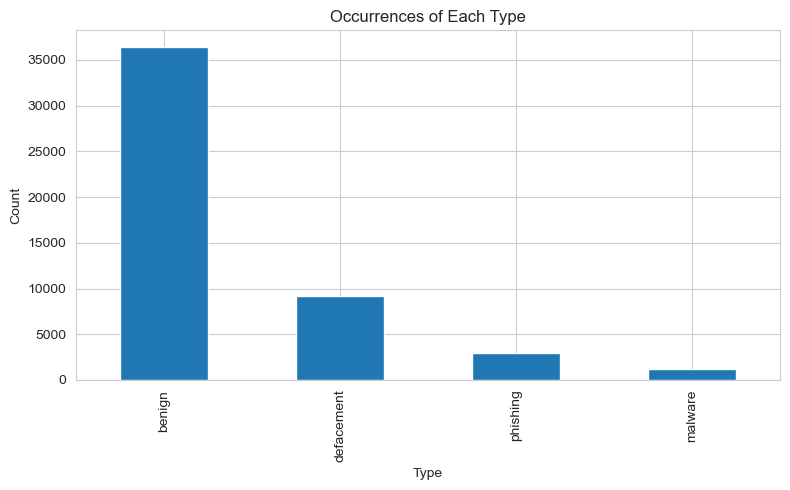

In [21]:
# TODO: Perform univariate analysis — explore distributions of individual features.
# Example: Histograms for numerical columns

counts = df['type'].value_counts()

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Bar chart
counts.plot(kind='bar', ax=ax)

# Labels and title
ax.set_title("Occurrences of Each Type")
ax.set_xlabel("Type")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

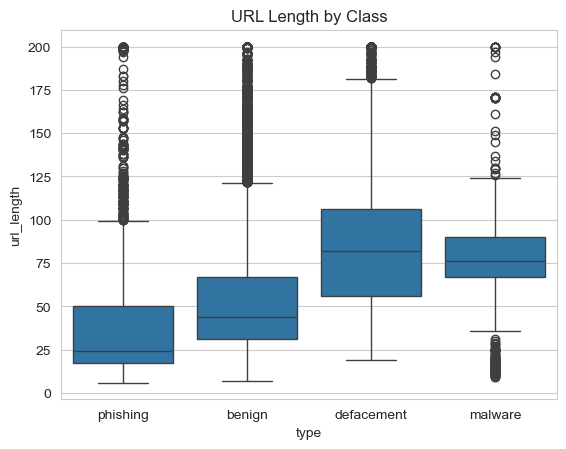

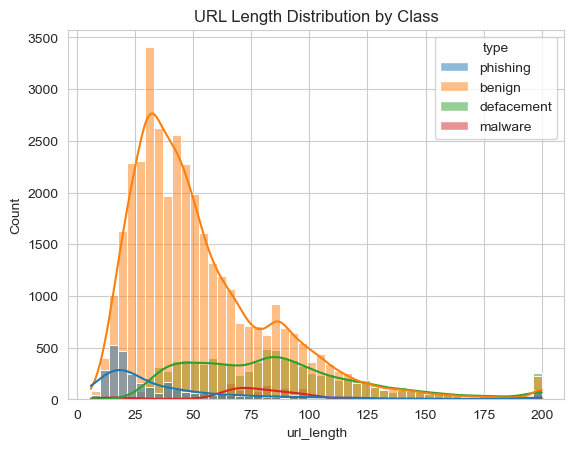

In [22]:
# TODO: Perform bivariate/multivariate analysis — explore relationships between features.
# Example: Correlation heatmap
df['url_length'] = df['url'].apply(len)
sns.boxplot(data=df, x='type', y='url_length')
plt.title("URL Length by Class")
plt.show()

sns.histplot(data=df, x='url_length', hue='type', bins=50, kde=True)
plt.title("URL Length Distribution by Class")
plt.show()

In [23]:
# TODO: Document any initial insights or hypotheses from your exploration.

initial_insights = [
    "Insight 1: The dataset consists of raw URL strings and a categorical target variable (type), meaning it requires transformation before modeling.",
    
    "Insight 2: The class distribution shows potential imbalance between benign, phishing, and malware URLs, which may affect model performance.",
    
    "Insight 3: URL lengths vary across classes, with malicious URLs tending to be longer on average, suggesting possible obfuscation behavior.",
    
    "Insight 4: The dataset lacks explicit numerical features, indicating that meaningful features must be extracted from the URL structure in later stages.",
    
    "Hypothesis 1: Longer URLs are more likely to be associated with phishing or malware due to obfuscation techniques.",
    
    "Hypothesis 2: The presence of unusual patterns (e.g., excessive characters or complex structures) in URLs can help distinguish malicious URLs from benign ones.",
    
    "Hypothesis 3: Class imbalance, if present, will require handling (e.g., resampling or weighting) to ensure robust model performance."
]

for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")

1. Insight 1: The dataset consists of raw URL strings and a categorical target variable (type), meaning it requires transformation before modeling.
2. Insight 2: The class distribution shows potential imbalance between benign, phishing, and malware URLs, which may affect model performance.
3. Insight 3: URL lengths vary across classes, with malicious URLs tending to be longer on average, suggesting possible obfuscation behavior.
4. Insight 4: The dataset lacks explicit numerical features, indicating that meaningful features must be extracted from the URL structure in later stages.
5. Hypothesis 1: Longer URLs are more likely to be associated with phishing or malware due to obfuscation techniques.
6. Hypothesis 2: The presence of unusual patterns (e.g., excessive characters or complex structures) in URLs can help distinguish malicious URLs from benign ones.
7. Hypothesis 3: Class imbalance, if present, will require handling (e.g., resampling or weighting) to ensure robust model performa

---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [24]:
# TODO: Check for missing values.
df_check = df.drop(columns=[df.columns[0]])
missing = df_check.isnull().sum()
missing_pct = (df_check.isnull().sum() / len(df_check)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("=== Missing Values Report ===")
print(missing_report)
print(f"\nTotal columns with missing values: {len(missing_report)}")

=== Missing Values Report ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total columns with missing values: 0


In [25]:
# TODO: Check for duplicate records.

duplicates = df_check.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nSample of duplicate rows (grouped together):")

    # Get all duplicate rows
    dup_df = df_check[df_check.duplicated(keep=False)]

    # Sort by all columns so identical rows appear next to each other
    dup_df = dup_df.sort_values(by=list(df_check.columns))

    print(dup_df.head(10))

Number of duplicate rows: 9311

Sample of duplicate rows (grouped together):
                                                     url      type  url_length
17252     1001crash.com/index-page-liste_noire-lg-2.html    benign          46
26202     1001crash.com/index-page-liste_noire-lg-2.html    benign          46
20609   100league0flegends00mystery001.000webhostapp.com  phishing          48
29559   100league0flegends00mystery001.000webhostapp.com  phishing          48
17897                            104infdiv.org/CROSS.HTM    benign          23
26847                            104infdiv.org/CROSS.HTM    benign          23
21430  10starmovies.com/Watch-Movies-Online/Inside_Im...    benign          60
30380  10starmovies.com/Watch-Movies-Online/Inside_Im...    benign          60
22478                               1149productions.com/    benign          20
31428                               1149productions.com/    benign          20


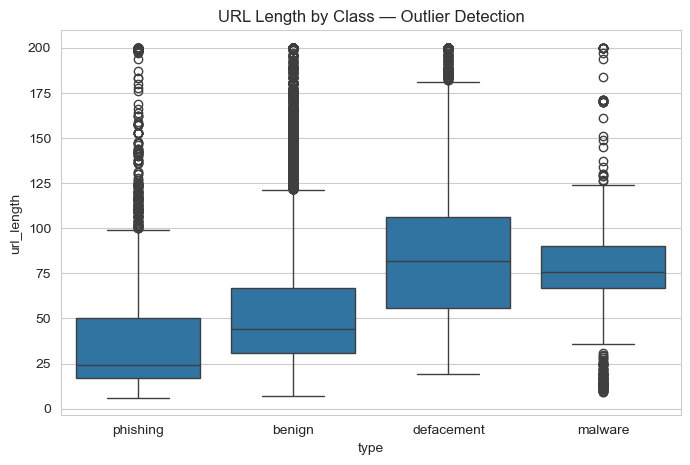

In [26]:
# TODO: Detect outliers using box plots or statistical methods.

# numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# if numerical_cols:
#     fig, axes = plt.subplots(nrows=1, ncols=len(numerical_cols), figsize=(4 * len(numerical_cols), 5))
#     if len(numerical_cols) == 1:
#         axes = [axes]
#     for ax, col in zip(axes, numerical_cols):
#         ax.boxplot(df[col].dropna())
#         ax.set_title(col)
#     plt.suptitle('Box Plots — Outlier Detection', fontsize=14, y=1.02)
#     plt.tight_layout()
#     plt.show()

df['url_length'] = df['url'].apply(len)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='type', y='url_length')
plt.title("URL Length by Class — Outlier Detection")
plt.show()